# RAG QA Logs & Corpus

**Ops, risk, and retrieval-evaluation diagnostics for synthetic RAG QA logs.**

This notebook turns a **synthetic, multi-table RAG evaluation corpus** into **practical evaluation signals** for retrieval behavior, answer quality, cost, and latency.

The analysis follows the system end-to-end — from **documents and chunks** to **retrieval events** to **QA evaluation runs** — and answers four practical questions:

- **Failure attribution:** is the miss coming from **retrieval** coverage or **generation** quality?
- **Risk concentration:** which slices show higher risk across **domain**, **scenario type**, and **difficulty**?
- **Config selection:** which **retrieval + model** setup performs best when quality, cost, and latency trade off?
- **Offline threshold simulation:** how would a probability threshold affect coverage and error on already-labeled evaluation logs?

**Scope note:** this dataset is a synthetic/offline evaluation artifact. It is useful for analysis, benchmarking, and RAG observability practice. It is **not live customer telemetry** and the baseline model below is **diagnostic**, not a deployable production policy.

**Dataset requirement:** attach the companion Kaggle dataset **RAG QA Logs & Corpus Data** before running. Expected files are: `rag_corpus_documents.csv`, `rag_corpus_chunks.csv`, `eval_runs.csv`, `rag_retrieval_events.csv`, `scenarios.csv`, and optionally `data_dictionary.csv`.

**Output:** compact tables and plots for KPI baselines, risk slices, configuration frontiers, failure attribution, and threshold trade-offs.

In [1]:

from IPython.display import HTML, display

INTRO_HTML = r'''
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700;900&display=swap');

.nb-hero-wrap{ width: 100%; box-sizing: border-box; margin: 0; }
.nb-hero{ max-width: 1100px; margin: 0 auto; padding: 34px 22px; }
.nb-cards{ display: grid; grid-template-columns: 1fr; gap: 12px; margin-top: 14px; }
.nb-card{ background: rgba(255,255,255,0.08); padding: 16px; border-radius: 14px; border: 1px solid rgba(255,255,255,0.10); }
@media (max-width: 640px){ .nb-hero{ padding: 24px 14px; } }
</style>

<div class="nb-hero-wrap" style="
  background: radial-gradient(1200px 420px at 50% 0%, rgba(102,227,255,0.14), transparent 55%),
              linear-gradient(135deg, #0b1220, #0f2a4a);
  border-radius: 18px;
  color: #e8f0ff;
  font-family: Inter, ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Arial, sans-serif;
  border: 1px solid rgba(255,255,255,0.12);
  box-shadow: 0 14px 36px rgba(0,0,0,0.18);
  overflow: hidden;
">
  <div class="nb-hero">
    <div style="text-align:center;">
      <div style="font-size:clamp(28px, 4.2vw, 42px); font-weight:900; letter-spacing:0.2px; line-height:1.12;">
        RAG QA Logs &amp; Corpus
      </div>
      <div style="margin-top:10px; font-size:clamp(14px, 1.6vw, 16px); color: rgba(232,240,255,0.88); line-height:1.75;">
        Offline RAG evaluation logs: retrieval quality, answer risk, cost, latency, and trade-offs.
      </div>
    </div>

    <div style="margin:18px 0 14px 0; height:1px; background: rgba(255,255,255,0.14);"></div>

    <div class="nb-cards">
      <div class="nb-card">
        <div style="font-weight:850; color:#66e3ff; margin-bottom:6px;">What you’ll do</div>
        <div style="font-size:15px; line-height:1.85; color: rgba(232,240,255,0.92);">
          Load the tables, verify joins &amp; uniqueness, review coverage, inspect failure slices, and train one diagnostic baseline model to estimate how much signal exists in the logs.
        </div>
      </div>

      <div class="nb-card">
        <div style="font-weight:850; color:#b9a7ff; margin-bottom:6px;">What you’ll get</div>
        <div style="font-size:15px; line-height:1.85; color: rgba(232,240,255,0.92);">
          KPI baselines, risk slices, configuration trade-offs, retrieval vs answer failure attribution,
          and an offline threshold simulation (coverage vs error).
        </div>
      </div>
    </div>

    <div style="margin-top:14px; display:flex; flex-wrap:wrap; gap:10px;">
      <span style="padding:6px 10px; border-radius:999px; background: rgba(255,255,255,0.10);
        border:1px solid rgba(255,255,255,0.10); font-size:12px;">Data</span>
      <span style="padding:6px 10px; border-radius:999px; background: rgba(255,255,255,0.10);
        border:1px solid rgba(255,255,255,0.10); font-size:12px;">Quality</span>
      <span style="padding:6px 10px; border-radius:999px; background: rgba(255,255,255,0.10);
        border:1px solid rgba(255,255,255,0.10); font-size:12px;">Slices</span>
      <span style="padding:6px 10px; border-radius:999px; background: rgba(255,255,255,0.10);
        border:1px solid rgba(255,255,255,0.10); font-size:12px;">Costs</span>
      <span style="padding:6px 10px; border-radius:999px; background: rgba(255,255,255,0.10);
        border:1px solid rgba(255,255,255,0.10); font-size:12px;">Thresholds</span>
    </div>
  </div>
</div>
'''
display(HTML(INTRO_HTML))


In [2]:
from __future__ import annotations

from pathlib import Path
import sys
from typing import Iterable, Optional

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from IPython.display import HTML, display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.calibration import calibration_curve

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 160)

print(
    "Versions:",
    f"python={sys.version.split()[0]}",
    f"pandas={pd.__version__}",
    f"numpy={np.__version__}",
    f"sklearn={sklearn.__version__}",
    sep=" | ",
)


RANDOM_STATE = 42
TOP_K_CHUNKS_TO_SHOW = 5
MIN_SLICE_N = 30
MIN_SEGMENT_N = 15

# Treat retrieval as acceptable when at least 80% of expected evidence is recovered in the top 10.
# This is an offline analysis threshold, not a universal production target.
RETRIEVAL_OK_THRESHOLD = 0.80
THRESHOLDS = np.linspace(0.10, 0.90, 9)

# Shared result tables used by the final takeaways section. Initializing them prevents
# stale notebook-state reads when cells are re-run interactively or out of order.
scenario_risk_table = pd.DataFrame()
config_score_table = pd.DataFrame()
retrieval_outcome_table = pd.DataFrame()
threshold_simulation_table = pd.DataFrame()

DATA_FILES = {
    "documents": "rag_corpus_documents.csv",
    "chunks": "rag_corpus_chunks.csv",
    "eval_runs": "eval_runs.csv",
    "retrieval_events": "rag_retrieval_events.csv",
    "scenarios": "scenarios.csv",
    "data_dictionary": "data_dictionary.csv",
}


Versions: | python=3.12.12 | pandas=2.3.3 | numpy=2.0.2 | sklearn=1.6.1


In [3]:

NOTEBOOK_CSS = r'''
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700;900&display=swap');

:root{
  --stroke: rgba(15,23,42,0.14);
  --text: #0b1220;
  --muted: rgba(11,18,32,0.75);

  --accent: #0ea5e9;
  --good: #16a34a;
  --warn: #f59e0b;
  --bad:  #ef4444;

  --font: Inter, ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Arial;

  --surface: #ffffff;
  --section_bg: linear-gradient(90deg, rgba(14,165,233,0.12), rgba(2,6,23,0.02));
  --call_bg: #ffffff;

  --tbl_bg: #ffffff;
  --tbl_text: #0b1220;
  --tbl_head_bg: #0f172a;
  --tbl_head_text: #ffffff;
  --tbl_border: #e5e7eb;
  --tbl_row_alt: #f3f4f6;
  --tbl_row_hover: #e0f2fe;
}

html[data-color-mode="dark"],
body[data-color-mode="dark"],
html[data-theme="dark"],
body[data-theme="dark"],
body.kaggle-theme--dark,
body.theme-dark,
.dark{
  --stroke: rgba(255,255,255,0.12);
  --text: #e8f0ff;
  --muted: rgba(232,240,255,0.84);

  --accent: #66e3ff;
  --good: #38bdf8;
  --warn: #fbbf24;
  --bad:  #fb7185;

  --surface: #0b1220;
  --section_bg: linear-gradient(90deg, rgba(102,227,255,0.16), rgba(255,255,255,0.02));
  --call_bg: rgba(255,255,255,0.06);

  --tbl_bg: #0b1220;
  --tbl_text: #e8f0ff;
  --tbl_head_bg: #0b1220;
  --tbl_head_text: #e8f0ff;
  --tbl_border: rgba(255,255,255,0.14);
  --tbl_row_alt: #0f172a;
  --tbl_row_hover: #102a43;
}

.rendered_html, .jp-RenderedHTMLCommon{ font-size: 16px; line-height: 1.65; }

.nb-section{
  margin:22px 0 14px 0;
  padding:16px 18px;
  border-left: 6px solid var(--accent);
  background: var(--section_bg);
  border-radius: 16px;
  font-family: var(--font);
  border: 1px solid var(--stroke);
}
.nb-section h2{ margin:0; font-size:26px; font-weight:900; color:var(--text); letter-spacing:0.2px; }
.nb-section p{ margin:8px 0 0 0; color:var(--muted); line-height:1.8; font-size:16px; }

.nb-call{
  margin:16px 0;
  padding:16px 18px;
  border-radius:16px;
  font-family:var(--font);
  border:1px solid var(--stroke);
  background: var(--call_bg);
}
.nb-call.good{ border-left:6px solid var(--good); }
.nb-call.warn{ border-left:6px solid var(--warn); }
.nb-call.bad{  border-left:6px solid var(--bad);  }
.nb-call .t{ font-weight:900; color:var(--text); margin-bottom:8px; font-size:18px; }
.nb-call .d{ color:var(--muted); line-height:1.8; font-size:16px; }

.nb-kpis{
  display:grid;
  grid-template-columns: repeat(4, minmax(0, 1fr));
  gap:14px;
  margin:14px 0 6px 0;
}
.nb-kpi{
  background: rgba(255,255,255,0.70);
  border:1px solid var(--stroke);
  border-radius:16px;
  padding:14px 14px;
  font-family:var(--font);
}
html[data-color-mode="dark"] .nb-kpi,
body.kaggle-theme--dark .nb-kpi,
.dark .nb-kpi{ background: rgba(255,255,255,0.06); }
.nb-kpi .k{ font-size:14px; color:var(--muted); margin-bottom:8px; }
.nb-kpi .v{ font-size:24px; font-weight:900; color:var(--text); line-height:1.1; }
.nb-kpi .s{ font-size:14px; color:var(--muted); margin-top:6px; line-height:1.4; }
@media (max-width: 980px){ .nb-kpis{ grid-template-columns: repeat(2, minmax(0,1fr)); } }

table.dataframe{
  background-color: var(--tbl_bg) !important;
  color: var(--tbl_text) !important;
  border: 1px solid var(--tbl_border) !important;
  border-radius: 16px;
  overflow: hidden;
  font-size: 15px;
}
table.dataframe thead th{
  background-color: var(--tbl_head_bg) !important;
  color: var(--tbl_head_text) !important;
  font-weight: 900;
  text-align: center;
  border-bottom: 1px solid var(--tbl_border) !important;
  padding: 12px 12px;
  white-space: nowrap;
}
table.dataframe tbody td{
  background-color: var(--tbl_bg) !important;
  color: var(--tbl_text) !important;
  border-bottom: 1px solid var(--tbl_border) !important;
  padding: 12px 12px;
  vertical-align: top;
  line-height: 1.55;
}
table.dataframe tbody tr:nth-child(even) td{ background-color: var(--tbl_row_alt) !important; }
table.dataframe tbody tr:hover td{ background-color: var(--tbl_row_hover) !important; }

div.output_area pre, .jp-OutputArea pre, .output pre{ font-size: 14px !important; line-height: 1.55 !important; }
.CodeMirror pre, .jp-CodeMirrorEditor .cm-content{ font-size: 14px !important; line-height: 1.6 !important; }
</style>
'''
display(HTML(NOTEBOOK_CSS))

def section(title: str, desc: str) -> None:
    display(HTML(f"<div class='nb-section'><h2>{title}</h2><p>{desc}</p></div>"))

def callout(kind: str, title: str, desc: str) -> None:
    kind = kind if kind in {"good","warn","bad"} else "good"
    display(HTML(f"<div class='nb-call {kind}'><div class='t'>{title}</div><div class='d'>{desc}</div></div>"))

def kpi_row(items) -> None:
    cards = ""
    for it in items:
        cards += f"<div class='nb-kpi'><div class='k'>{it['k']}</div><div class='v'>{it['v']}</div><div class='s'>{it['s']}</div></div>"
    display(HTML(f"<div class='nb-kpis'>{cards}</div>"))

def style_table(df: pd.DataFrame, max_rows: int = 30, wrap_cols=None, max_width_px=None, center_cols=None):
    wrap_cols = set(wrap_cols or [])
    max_width_px = dict(max_width_px or {})
    center_cols = set(center_cols or [])

    view = df.head(max_rows).copy()

    for c in view.columns:
        lc = str(c).lower()
        if any(k in lc for k in ["query","answer","title","snippet","text","description"]):
            wrap_cols.add(c)
            max_width_px.setdefault(c, 680)
        if str(view[c].dtype).startswith(("int","float","bool")):
            center_cols.add(c)

    st = view.style.hide(axis="index")
    if center_cols:
        cols = [c for c in center_cols if c in view.columns]
        st = st.set_properties(subset=cols, **{"text-align":"center"})
    if wrap_cols:
        cols = [c for c in wrap_cols if c in view.columns]
        st = st.set_properties(subset=cols, **{"white-space":"normal", "word-break":"break-word"})
    for col, w in max_width_px.items():
        if col in view.columns:
            st = st.set_properties(subset=[col], **{"max-width": f"{int(w)}px"})
    return st

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9.6, 5.4)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 12.5


In [4]:
def find_first_file(filename: str, roots: Iterable[Path]) -> Path:
    '''Return the first matching file under common Kaggle/local roots.'''
    matches: list[Path] = []
    for root in roots:
        if not root.exists():
            continue
        matches.extend(sorted(root.rglob(filename)))
    if not matches:
        searched = ", ".join(str(r) for r in roots)
        expected = ", ".join(DATA_FILES.values())
        raise FileNotFoundError(
            f"Could not find {filename!r}. Searched: {searched}.\n\n"
            "Hint: attach the companion Kaggle dataset via Data > Add Data, "
            "or place the CSV files under a local data/ directory.\n"
            f"Expected files: {expected}"
        )
    return matches[0]

SEARCH_ROOTS = [
    Path("/kaggle/input"),
    Path.cwd(),
    Path.cwd().parent,
    Path("../input"),
    Path("data"),
    Path("docs"),
]

DOCS_PATH = find_first_file(DATA_FILES["documents"], SEARCH_ROOTS)
DATA_DIR = DOCS_PATH.parent

try:
    DICT_PATH = find_first_file(DATA_FILES["data_dictionary"], SEARCH_ROOTS)
    DOCS_DIR = DICT_PATH.parent
except FileNotFoundError:
    DICT_PATH = None
    DOCS_DIR = DATA_DIR.parent / "docs"

def display_path_for_environment(path: Path) -> str:
    """Display Kaggle paths directly and avoid leaking local machine paths in saved outputs."""
    path_str = str(path)
    if path_str.startswith("/kaggle/input"):
        return path_str
    return f"{path.name} (local execution; on Kaggle this resolves under /kaggle/input/... when the dataset is attached)"

print("DATA_DIR:", display_path_for_environment(DATA_DIR))
print("DOCS_DIR:", display_path_for_environment(DOCS_DIR))


def load_csv(filename: str, base_dir: Path = DATA_DIR) -> pd.DataFrame:
    path = base_dir / filename
    if not path.exists():
        path = find_first_file(filename, SEARCH_ROOTS)
    df = pd.read_csv(path)
    print(f"{filename:<26} shape={df.shape}")
    return df


section("Load data", "Load all tables and build a quick summary of shapes.")

docs = load_csv(DATA_FILES["documents"])
chunks = load_csv(DATA_FILES["chunks"])
eval_runs = load_csv(DATA_FILES["eval_runs"])
retrieval = load_csv(DATA_FILES["retrieval_events"])
scenarios = load_csv(DATA_FILES["scenarios"])

tables = {
    "documents": docs,
    "chunks": chunks,
    "eval_runs": eval_runs,
    "retrieval_events": retrieval,
    "scenarios": scenarios,
}

table_summary = pd.DataFrame({
    "table": list(tables.keys()),
    "n_rows": [len(df) for df in tables.values()],
    "n_cols": [df.shape[1] for df in tables.values()],
}).sort_values("table").reset_index(drop=True)

display(style_table(table_summary, max_rows=10, center_cols=["n_rows", "n_cols"]))


DATA_DIR: /kaggle/input/datasets/tarekmasryo/rag-qa-evaluation-logs-and-corpus/data
DOCS_DIR: /kaggle/input/datasets/tarekmasryo/rag-qa-evaluation-logs-and-corpus/docs


rag_corpus_documents.csv   shape=(658, 19)
rag_corpus_chunks.csv      shape=(5237, 6)
eval_runs.csv              shape=(3824, 49)
rag_retrieval_events.csv   shape=(93375, 12)
scenarios.csv              shape=(62, 13)


table,n_rows,n_cols
chunks,5237,6
documents,658,19
eval_runs,3824,49
retrieval_events,93375,12
scenarios,62,13


In [5]:
data_dictionary = None
if DICT_PATH is not None and Path(DICT_PATH).exists():
    data_dictionary = pd.read_csv(DICT_PATH)
    section("Data dictionary", "Schema helper loaded from the docs folder.")
    display(style_table(
        data_dictionary,
        max_rows=25,
        wrap_cols=["column_name", "description"],
        max_width_px={"description": 720},
    ))
else:
    callout("warn", "Data dictionary", "No data_dictionary.csv file was found; continuing with table-level checks.")


table_name,column_name,dtype,description,allowed_values
rag_corpus_documents,doc_id,string,Unique identifier for each document.,Pattern: DOC[0-9]{4}
rag_corpus_documents,domain,string,"High level domain or category of the document (support, product_docs, medical_guides, etc.).","customer_success, data_platform_docs, developer_docs, financial_reports, hr_policies, marketing_analytics, medical_guides, mlops_docs, policies, product_docs, research_papers, support_faq"
rag_corpus_documents,title,text,Short title of the document.,nan
rag_corpus_documents,source_type,category,"Source type of the document (kb_article, runbook, policy_pdf, report, etc.).","internal_doc, notebook, pdf_manual, policy_file, spreadsheet, web_article, wiki_page"
rag_corpus_documents,language,string,"Language of the document, usually ISO language code (e.g., en).",en
rag_corpus_documents,n_sections,int,Number of logical sections inside the document.,nan
rag_corpus_documents,n_tokens,int,Estimated total token count for the full document.,nan
rag_corpus_documents,n_chunks,int,Number of chunks the document is split into for retrieval.,nan
rag_corpus_documents,avg_chunk_tokens,float,Average token count per chunk for this document.,nan
rag_corpus_documents,created_at_utc,datetime,UTC timestamp when the document was first created in the corpus.,nan


In [6]:

def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")

def q(x: pd.Series, quant: float) -> float:
    s = to_num(x).dropna()
    return float(s.quantile(quant)) if len(s) else float("nan")

def assert_unique(df: pd.DataFrame, key: str, name: str) -> None:
    if key not in df.columns:
        return
    d = int(df[key].duplicated().sum())
    if d:
        raise ValueError(f"{name}.{key} duplicates={d}")

def assert_fk(child: pd.Series, parent: pd.Series, name: str) -> None:
    a = set(pd.Series(child).dropna().unique())
    b = set(pd.Series(parent).dropna().unique())
    miss = list(a - b)
    if miss:
        raise ValueError(f"{name} missing={len(miss)}")

def compact_info(df: pd.DataFrame, name: str) -> pd.DataFrame:
    return (
        pd.DataFrame({
            "table": name,
            "column": df.columns,
            "dtype": [str(t) for t in df.dtypes],
            "nulls": df.isna().sum().values,
            "null_rate": (df.isna().mean().values).round(4),
        })
        .sort_values(["table","null_rate"], ascending=[True, False])
        .reset_index(drop=True)
    )

def clip_text(x: object, n: int = 240) -> str:
    s = "" if (x is None or (isinstance(x, float) and np.isnan(x))) else str(x)
    s = " ".join(s.split())
    return (s[:n] + "…") if len(s) > n else s

section("Integrity checks", "Verify uniqueness and key consistency for safe slicing.")

assert_unique(docs, "doc_id", "docs")
assert_unique(chunks, "chunk_id", "chunks")
assert_unique(eval_runs, "run_id", "eval_runs")
assert_unique(scenarios, "scenario_id", "scenarios")

if "doc_id" in chunks.columns and "doc_id" in docs.columns:
    assert_fk(chunks["doc_id"], docs["doc_id"], "chunks.doc_id -> docs.doc_id")
if retrieval is not None and "chunk_id" in retrieval.columns and "chunk_id" in chunks.columns:
    assert_fk(retrieval["chunk_id"], chunks["chunk_id"], "retrieval.chunk_id -> chunks.chunk_id")
if retrieval is not None and "run_id" in retrieval.columns and "run_id" in eval_runs.columns:
    assert_fk(retrieval["run_id"], eval_runs["run_id"], "retrieval.run_id -> eval_runs.run_id")
if "scenario_id" in eval_runs.columns and "scenario_id" in scenarios.columns:
    assert_fk(eval_runs["scenario_id"], scenarios["scenario_id"], "eval_runs.scenario_id -> scenarios.scenario_id")

callout("good", "OK", "Keys look consistent; slice analysis and comparisons are built on safe joins.")


In [7]:

section("Schema snapshot", "Dtypes and missingness for quick scanning.")
schema_view = pd.concat([compact_info(df, name) for name, df in tables.items()], ignore_index=True)
display(style_table(schema_view, max_rows=30))


table,column,dtype,nulls,null_rate
documents,doc_id,object,0,0.000000
documents,domain,object,0,0.000000
documents,title,object,0,0.000000
documents,source_type,object,0,0.000000
documents,language,object,0,0.000000
documents,n_sections,int64,0,0.000000
documents,n_tokens,int64,0,0.000000
documents,n_chunks,int64,0,0.000000
documents,avg_chunk_tokens,float64,0,0.000000
documents,created_at_utc,object,0,0.000000


In [8]:

section("KPI snapshot", "Rates and tail metrics for latency and cost (based on available columns).")

kpi = {"n_eval_runs": float(len(eval_runs))}

if "is_correct" in eval_runs.columns:
    s = to_num(eval_runs["is_correct"])
    kpi["correct_label_coverage"] = float(s.notna().mean())
    kpi["correct_rate"] = float(s.mean())

if "hallucination_flag" in eval_runs.columns:
    h = to_num(eval_runs["hallucination_flag"])
    kpi["hallucination_label_coverage"] = float(h.notna().mean())
    kpi["hallucination_rate"] = float(h.mean())

if "total_cost_usd" in eval_runs.columns:
    kpi["avg_cost_usd"] = float(to_num(eval_runs["total_cost_usd"]).mean())
    kpi["p95_cost_usd"] = float(q(eval_runs["total_cost_usd"], 0.95))

if "total_latency_ms" in eval_runs.columns:
    kpi["avg_latency_ms"] = float(to_num(eval_runs["total_latency_ms"]).mean())
    kpi["p95_latency_ms"] = float(q(eval_runs["total_latency_ms"], 0.95))

if "recall_at_10" in eval_runs.columns:
    kpi["avg_recall_at_10"] = float(to_num(eval_runs["recall_at_10"]).mean())
if "mrr_at_10" in eval_runs.columns:
    kpi["avg_mrr_at_10"] = float(to_num(eval_runs["mrr_at_10"]).mean())

kpi_tbl = pd.DataFrame([{"metric": k, "value": v} for k, v in kpi.items()])
display(style_table(kpi_tbl, max_rows=25, center_cols=["value"]))

kpi_row([
    {"k":"Correct rate", "v": f"{kpi.get('correct_rate', np.nan):.3f}" if "correct_rate" in kpi else "—", "s":"Higher is better"},
    {"k":"Hallucination rate", "v": f"{kpi.get('hallucination_rate', np.nan):.3f}" if "hallucination_rate" in kpi else "—", "s":"Lower is safer"},
    {"k":"Avg cost (USD)", "v": f"{kpi.get('avg_cost_usd', np.nan):.4f}" if "avg_cost_usd" in kpi else "—", "s":"Budget pressure"},
    {"k":"p95 latency (ms)", "v": f"{kpi.get('p95_latency_ms', np.nan):.0f}" if "p95_latency_ms" in kpi else "—", "s":"Tail latency matters"},
])


metric,value
n_eval_runs,3824.000000
correct_label_coverage,1.000000
correct_rate,0.743985
hallucination_label_coverage,1.000000
hallucination_rate,0.190115
avg_cost_usd,0.000986
p95_cost_usd,0.004360
avg_latency_ms,948.618724
p95_latency_ms,1849.850000
avg_recall_at_10,0.895229


domain,docs_fraction,eval_fraction
financial_reports,0.132219,0.201621
developer_docs,0.112462,0.192730
hr_policies,0.118541,0.156381
medical_guides,0.118541,0.123169
product_docs,0.127660,0.094665
policies,0.109422,0.090481
support_faq,0.142857,0.071914
research_papers,0.126140,0.069038
other,0.012158,0.000000


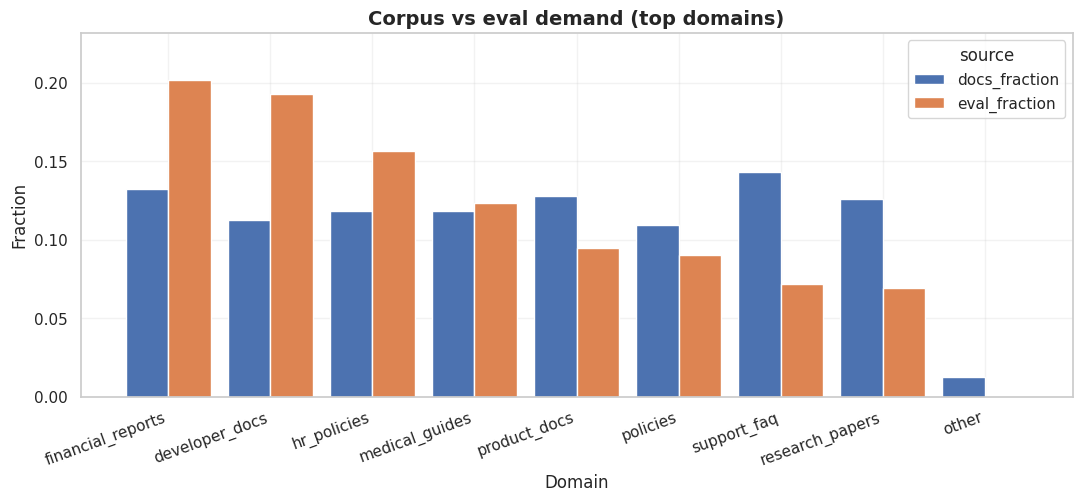

In [9]:
section("Coverage vs demand", "Compare corpus distribution to evaluation demand (top domains + other).")

TOP_N = 8
EPS = 1e-12

if ("domain" in docs.columns) and ("domain" in eval_runs.columns):
    doc_domain = docs["domain"].value_counts(normalize=True).rename("docs_fraction")
    run_domain = eval_runs["domain"].value_counts(normalize=True).rename("eval_fraction")

    dom = pd.concat([doc_domain, run_domain], axis=1).fillna(0.0).reset_index()
    # Make the domain column explicit across pandas versions / index-name behavior.
    first_col = dom.columns[0]
    if first_col != "domain":
        dom = dom.rename(columns={first_col: "domain"})

    dom = dom[(dom["docs_fraction"] > EPS) | (dom["eval_fraction"] > EPS)].copy()
    dom = dom.sort_values("eval_fraction", ascending=False).reset_index(drop=True)

    top = dom.head(TOP_N).copy()
    rest = dom.iloc[TOP_N:].copy()

    if len(rest):
        other = pd.DataFrame([{
            "domain": "other",
            "docs_fraction": float(rest["docs_fraction"].sum()),
            "eval_fraction": float(rest["eval_fraction"].sum()),
        }])
        dom_plot = pd.concat([top, other], ignore_index=True)
    else:
        dom_plot = top

    display(style_table(dom_plot, max_rows=25, center_cols=["docs_fraction", "eval_fraction"]))

    x = np.arange(len(dom_plot))
    w = 0.42

    plt.figure(figsize=(11.0, 5.2))
    plt.bar(x - w/2, dom_plot["docs_fraction"].values, width=w, label="docs_fraction")
    plt.bar(x + w/2, dom_plot["eval_fraction"].values, width=w, label="eval_fraction")

    plt.xticks(x, dom_plot["domain"].astype(str).values, rotation=20, ha="right")
    ymax = float(max(dom_plot["docs_fraction"].max(), dom_plot["eval_fraction"].max()))
    plt.ylim(0, ymax * 1.15 if ymax > 0 else 1.0)

    plt.ylabel("Fraction")
    plt.xlabel("Domain")
    plt.title("Corpus vs eval demand (top domains)")
    plt.legend(title="source")
    plt.tight_layout()
    plt.show()
else:
    callout("warn", "Coverage vs demand", "Column 'domain' missing in documents and/or eval_runs.")


difficulty,scenario_type,n_scenarios
easy,standard_qa,18
easy,no_answer_probe,2
hard,standard_qa,18
hard,no_answer_probe,3
medium,standard_qa,18
medium,no_answer_probe,3


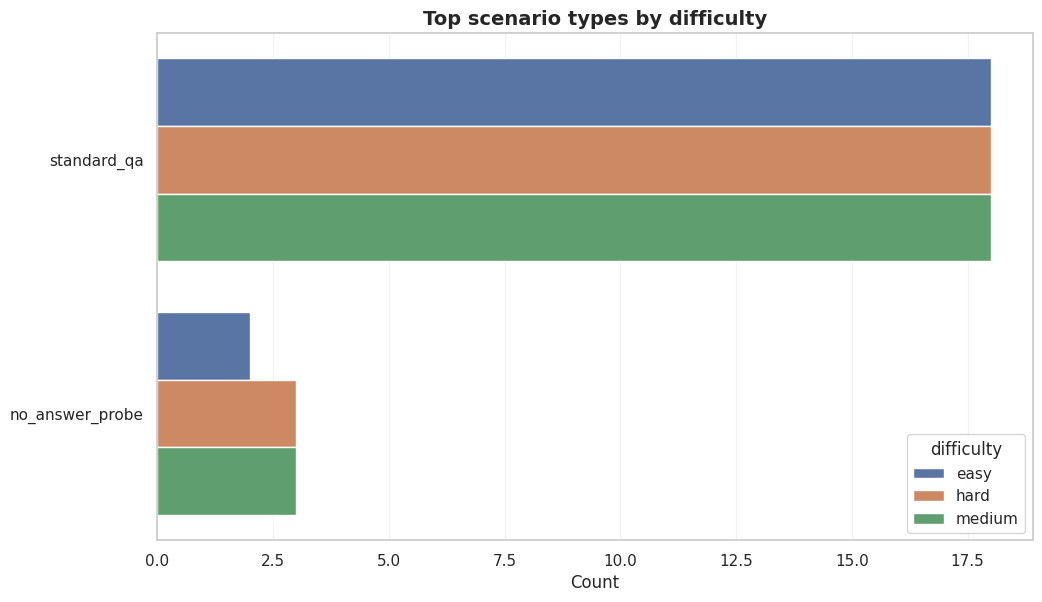

In [10]:

section("Scenario landscape", "Scenario types and difficulty (when columns exist).")

scn = scenarios.copy()
if "difficulty_level" in scn.columns and "difficulty" not in scn.columns:
    scn = scn.rename(columns={"difficulty_level":"difficulty"})

need = {"scenario_type","difficulty"}
if need.issubset(scn.columns):
    scen_summary = scn.groupby(["difficulty","scenario_type"])["scenario_id"].count().rename("n_scenarios").reset_index()
    scen_summary = scen_summary.sort_values(["difficulty","n_scenarios"], ascending=[True, False])
    display(style_table(scen_summary, max_rows=30))

    top_types = scen_summary.groupby("scenario_type")["n_scenarios"].sum().sort_values(ascending=False).head(12).index
    plt.figure(figsize=(10.6, 6.2))
    sns.countplot(data=scn[scn["scenario_type"].isin(top_types)], y="scenario_type", hue="difficulty", order=top_types)
    plt.title("Top scenario types by difficulty")
    plt.xlabel("Count")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    callout("warn", "Skipped", "Missing 'scenario_type' and/or 'difficulty' in scenarios.")


In [11]:

section("Example drill-downs", "Query → retrieved chunks (top-k) → outcome.")

def pick_example(df: pd.DataFrame, correct: Optional[int] = None, hallucinated: Optional[int] = None) -> pd.Series:
    x = df.copy()
    if correct is not None and "is_correct" in x.columns:
        x = x[to_num(x["is_correct"]) == int(correct)]
    if hallucinated is not None and "hallucination_flag" in x.columns:
        x = x[to_num(x["hallucination_flag"]) == int(hallucinated)]
    if len(x) == 0:
        x = df
    return x.sample(1, random_state=RANDOM_STATE).iloc[0]

def show_run(row: pd.Series) -> None:
    run_id = row.get("run_id", None)

    cols = [c for c in ["run_id","example_id","domain","task_type","difficulty","scenario_id","query","gold_answer","is_correct","hallucination_flag","recall_at_10","mrr_at_10","total_latency_ms","total_cost_usd"] if c in eval_runs.columns]
    view = eval_runs.loc[eval_runs["run_id"] == run_id, cols].head(1).copy() if ("run_id" in eval_runs.columns and run_id is not None) else pd.DataFrame([row[cols]])

    if "query" in view.columns:
        view["query"] = view["query"].map(lambda x: clip_text(x, 260))
    if "gold_answer" in view.columns:
        view["gold_answer"] = view["gold_answer"].map(lambda x: clip_text(x, 260))
    display(style_table(view, max_rows=1, wrap_cols=["query","gold_answer"], max_width_px={"query": 720, "gold_answer": 720}))

    if retrieval is None or run_id is None or "run_id" not in retrieval.columns:
        return

    sub = retrieval[retrieval["run_id"] == run_id].copy()
    if len(sub) == 0:
        return

    if "rank" in sub.columns:
        sub = sub.sort_values("rank")
    elif "retrieval_score" in sub.columns:
        sub = sub.sort_values("retrieval_score", ascending=False)
    sub = sub.head(TOP_K_CHUNKS_TO_SHOW)

    if "chunk_id" in sub.columns and "chunk_id" in chunks.columns:
        sub = sub.merge(chunks, on="chunk_id", how="left", suffixes=("", "_chunk"))
    if "doc_id" in sub.columns and "doc_id" in docs.columns:
        doc_cols = ["doc_id"] + [c for c in ["title","domain"] if c in docs.columns]
        sub = sub.merge(docs[doc_cols], on="doc_id", how="left")

    if "chunk_text" in sub.columns:
        sub["chunk_snippet"] = sub["chunk_text"].map(lambda x: clip_text(x, 320))

    cols2 = [c for c in ["rank","chunk_id","doc_id","title","retrieval_score","is_relevant","chunk_index","estimated_tokens","chunk_snippet"] if c in sub.columns]
    display(style_table(sub[cols2], max_rows=TOP_K_CHUNKS_TO_SHOW, wrap_cols=["chunk_snippet"], max_width_px={"chunk_snippet": 720}))

row_ok = pick_example(eval_runs, correct=1, hallucinated=0)
callout("good", "Example", "Correct (sample).")
show_run(row_ok)

row_bad = pick_example(eval_runs, correct=0, hallucinated=1)
callout("bad", "Example", "Incorrect + hallucination (sample, when available).")
show_run(row_bad)


run_id,example_id,domain,task_type,difficulty,scenario_id,query,gold_answer,is_correct,hallucination_flag,recall_at_10,mrr_at_10,total_latency_ms,total_cost_usd
run_2258,QA002259,support_faq,summarization,medium,SC0061,Where can I check the status of my support ticket?,Ticket status is available on the support portal under 'My Requests'.,1,0,1.000000,1.000000,794,0.000091


rank,chunk_id,doc_id,title,retrieval_score,is_relevant,chunk_index,estimated_tokens,chunk_snippet
1,C01014,DOC0129,Support playbook: handling issue and reset tickets (2020),0.758587,1,19,93,"Below are a few paragraphs from a practical troubleshooting FAQ. In this section of 'Support playbook: handling issue and reset tickets (2020)' explains how to issue when users face reset issues. It walks through the steps that agents follow in the internal help center, highlighting common failure modes and when to esc…"
2,C00084,DOC0011,"Issue and Reset support guide (EMEA, 2019)",0.766625,1,7,92,"Here are a few paragraphs from a practical troubleshooting FAQ. In this section of 'Issue and Reset support guide (EMEA, 2019)' explains how to ticket when users face troubleshooting issues. It walks through the steps that agents follow in the internal help center, highlighting common failure modes and when to escalate…"
3,C00104,DOC0014,"Troubleshooting and Issue support guide (AMER, 2019)",0.651113,1,2,91,"Here are a few paragraphs from a practical troubleshooting FAQ. This part of 'Troubleshooting and Issue support guide (AMER, 2019)' explains how to troubleshooting when users face steps issues. It walks through the steps that agents follow in the internal help center, highlighting common failure modes and when to escal…"
4,C04901,DOC0615,"How to ticket — internal support article (Global, 2021)",0.392249,0,11,95,"This excerpt gathers a few paragraphs from a practical troubleshooting FAQ. In this section of 'How to ticket — internal support article (Global, 2021)' explains how to issue when users face ticket issues. It walks through the steps that agents follow in the internal help center, highlighting common failure modes and w…"
5,C01119,DOC0143,"How to reset — internal support article (APAC, 2019)",0.564585,1,0,96,"Here is a mid-section excerpt from a customer support knowledge base article. This opening section of 'How to reset — internal support article (APAC, 2019)' explains how to ticket when users face steps issues. It walks through the steps that agents follow in the internal help center, highlighting common failure modes a…"


run_id,example_id,domain,task_type,difficulty,scenario_id,query,gold_answer,is_correct,hallucination_flag,recall_at_10,mrr_at_10,total_latency_ms,total_cost_usd
run_2097,QA002098,developer_docs,comparison,hard,SC0003,How do I authenticate using API keys?,API keys are passed as a bearer token in the Authorization header.,0,1,1.000000,0.166667,627,0.000141


rank,chunk_id,doc_id,title,retrieval_score,is_relevant,chunk_index,estimated_tokens,chunk_snippet
1,C03290,DOC0410,Service-to-service auth and endpoint — engineering guide 2024,0.339959,0,8,83,"This portion is taken from developer documentation used by engineering teams. In this section of 'Service-to-service auth and endpoint — engineering guide 2024' focuses on how engineering teams use the API in day‑to‑day work. It covers authentication patterns, request and response shapes, and how to handle authenticati…"
2,C03234,DOC0406,Developer integration guide — Request and Api,0.446808,0,2,80,"This passage comes from developer documentation used by engineering teams. This part of 'Developer integration guide — Request and Api' focuses on how engineering teams use the API in day‑to‑day work. It covers authentication patterns, request and response shapes, and how to handle request safely in production. Code sn…"
3,C03256,DOC0406,Developer integration guide — Request and Api,0.757425,0,24,82,"This chunk contains part of a developer-facing guide or API reference. In this section of 'Developer integration guide — Request and Api' focuses on how engineering teams use the API in day‑to‑day work. It covers authentication patterns, request and response shapes, and how to handle api safely in production. Code snip…"
4,C03295,DOC0410,Service-to-service auth and endpoint — engineering guide 2024,0.784004,0,13,83,"This chunk contains part of a developer-facing guide or API reference. In this section of 'Service-to-service auth and endpoint — engineering guide 2024' focuses on how engineering teams use the API in day‑to‑day work. It covers authentication patterns, request and response shapes, and how to handle api safely in produ…"
5,C04775,DOC0600,Developer integration guide — Endpoint and Response,0.334509,0,0,82,"The following section comes from developer documentation used by engineering teams. This opening section of 'Developer integration guide — Endpoint and Response' focuses on how engineering teams use the API in day‑to‑day work. It covers authentication patterns, request and response shapes, and how to handle request saf…"


domain,scenario_type,difficulty,n_rows,correct_rate
financial_reports,standard_qa,hard,140,0.478571
hr_policies,standard_qa,hard,109,0.504587
policies,standard_qa,hard,50,0.540000
medical_guides,standard_qa,hard,68,0.544118
developer_docs,standard_qa,hard,129,0.565891
product_docs,standard_qa,hard,55,0.581818
support_faq,standard_qa,hard,43,0.651163
research_papers,standard_qa,medium,165,0.696970
research_papers,standard_qa,hard,51,0.705882
financial_reports,standard_qa,medium,489,0.730061


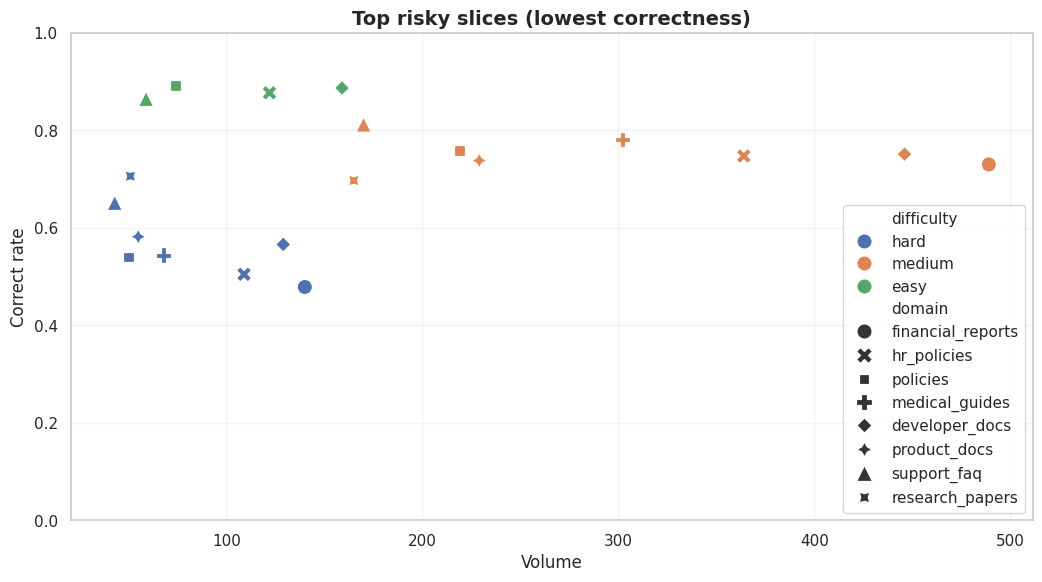

In [12]:
section("Scenario risk slices", "High-volume slices with low correctness (labeled subset).")

if "is_correct" in eval_runs.columns:
    labeled = eval_runs.copy()
    labeled["is_correct"] = to_num(labeled["is_correct"])
    labeled = labeled.dropna(subset=["is_correct"]).copy()
else:
    labeled = pd.DataFrame()

scn = scenarios.copy()
if "difficulty_level" in scn.columns and "scenario_difficulty" not in scn.columns:
    scn = scn.rename(columns={"difficulty_level": "scenario_difficulty"})
elif "difficulty" in scn.columns and "scenario_difficulty" not in scn.columns:
    scn = scn.rename(columns={"difficulty": "scenario_difficulty"})

need_runs = {"domain", "scenario_id", "is_correct"}
need_scn = {"scenario_id", "scenario_type"}

if need_runs.issubset(labeled.columns) and need_scn.issubset(scn.columns):
    scn_cols = ["scenario_id", "scenario_type"]
    if "scenario_difficulty" in scn.columns:
        scn_cols.append("scenario_difficulty")

    m = labeled.merge(scn[scn_cols], on="scenario_id", how="left")

    m["domain"] = m["domain"].fillna("unknown")
    m["scenario_type"] = m["scenario_type"].fillna("unknown")

    if "difficulty" in m.columns:
        m["difficulty"] = m["difficulty"].fillna(m.get("scenario_difficulty", "unknown"))
    elif "scenario_difficulty" in m.columns:
        m["difficulty"] = m["scenario_difficulty"].fillna("unknown")
    else:
        m["difficulty"] = "unknown"

    id_col = "example_id" if "example_id" in m.columns else ("run_id" if "run_id" in m.columns else "scenario_id")

    tbl = (
        m.groupby(["domain", "scenario_type", "difficulty"], dropna=False)
        .agg(n_rows=(id_col, "size"), correct_rate=("is_correct", "mean"))
        .reset_index()
    )
    tbl = tbl[tbl["n_rows"] >= MIN_SEGMENT_N].copy()
    tbl = tbl.sort_values(["correct_rate", "n_rows"], ascending=[True, False]).reset_index(drop=True)
    scenario_risk_table = tbl.copy()
    display(style_table(scenario_risk_table.head(30), max_rows=30, center_cols=["n_rows", "correct_rate"]))

    top = scenario_risk_table.head(20).copy()
    plt.figure(figsize=(10.6, 6.0))
    sns.scatterplot(data=top, x="n_rows", y="correct_rate", hue="difficulty", style="domain", s=120)
    plt.title("Top risky slices (lowest correctness)")
    plt.xlabel("Volume")
    plt.ylabel("Correct rate")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    callout("warn", "Skipped", "Need labeled is_correct + scenario metadata.")


component,direction,weight,reason
correct_rate,+,1.000000,Primary quality signal.
hallucination_rate,-,0.600000,Unsupported/wrong answers are high-risk.
latency_p95_scaled,-,0.150000,Operational latency penalty after robust scaling.
cost_p95_scaled,-,0.100000,Budget pressure penalty after robust scaling.


retrieval_strategy,generator_model,difficulty,n_rows,correct_rate,hallucination_rate,avg_latency_ms,avg_cost_usd,latency_p95_scaled,cost_p95_scaled,score
bm25_then_rerank,gpt-4o-mini,easy,53,0.962264,0.000000,685.169811,0.000157,0.516936,0.044184,0.880305
dense_then_rerank,gpt-4o-mini,easy,53,0.924528,0.037736,687.301887,0.000160,0.518544,0.045096,0.819596
hybrid,gpt-4o-mini,easy,47,0.914894,0.042553,655.425532,0.000147,0.494495,0.041352,0.811052
bm25_then_rerank,llama-3.1-8b-instruct,easy,34,0.911765,0.058824,785.205882,0.000070,0.592409,0.019539,0.785655
hybrid,gpt-4o,easy,31,0.935484,0.000000,999.774194,0.001902,0.754293,0.534372,0.768903
bm25,gpt-4o-mini,easy,37,0.810811,0.027027,637.594595,0.000143,0.481042,0.040322,0.718406
dense,gpt-4o,easy,33,0.969697,0.060606,1486.636364,0.002863,1.121613,0.804635,0.684628
dense_then_rerank,llama-3.1-70b-instruct,medium,38,0.868421,0.105263,1050.552632,0.000369,0.792604,0.103667,0.676006
dense,gpt-4o-mini,easy,38,0.815789,0.105263,668.368421,0.000148,0.504260,0.041480,0.672845
bm25,mistral-large,medium,46,0.847826,0.130435,957.521739,0.000395,0.722415,0.111064,0.650097


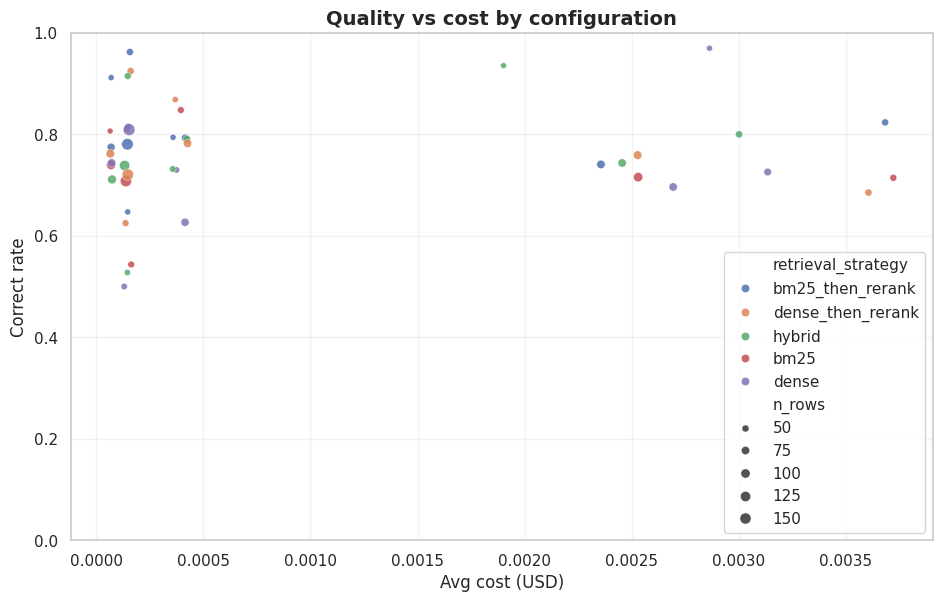

In [13]:
section("Configuration comparison", "Compare settings under quality × cost × latency constraints.")

group_cols = [c for c in ["retrieval_strategy", "generator_model", "difficulty"] if c in eval_runs.columns]
required_config_metrics = ["is_correct", "hallucination_flag", "total_latency_ms", "total_cost_usd"]

if not group_cols:
    callout("warn", "Skipped", "No configuration columns found.")
else:
    df = eval_runs.copy()
    missing_config_metrics = [c for c in required_config_metrics if c not in df.columns]

    if missing_config_metrics:
        callout(
            "warn",
            "Skipped",
            "Configuration comparison requires quality, hallucination, latency, and cost columns. "
            f"Missing columns: {', '.join(missing_config_metrics)}.",
        )
        config_score_table = pd.DataFrame()
    else:
        for c in required_config_metrics:
            df[c] = to_num(df[c])

        id_col = "run_id" if "run_id" in df.columns else group_cols[0]

        config_score_table = (
            df.groupby(group_cols, dropna=False)
            .agg(
                n_rows=(id_col, "size"),
                correct_rate=("is_correct", "mean"),
                hallucination_rate=("hallucination_flag", "mean"),
                avg_latency_ms=("total_latency_ms", "mean"),
                avg_cost_usd=("total_cost_usd", "mean"),
            )
            .reset_index()
        )

        config_score_table = config_score_table[config_score_table["n_rows"] >= MIN_SLICE_N].copy()

        # Heuristic ranking score for comparing configurations in one table.
        # This is not a learned objective. Latency and cost are robustly scaled to the 95th percentile
        # before weighting, so the score is not dominated by raw units such as milliseconds or USD.
        SCORE_WEIGHTS = {
            "hallucination_rate": 0.60,   # wrong-and-unsupported answers are penalized more than ops cost.
            "latency_p95_scaled": 0.15,   # latency matters, but should not outweigh correctness.
            "cost_p95_scaled": 0.10,      # small cost differences are secondary to answer quality.
        }

        def p95_scaled(series: pd.Series) -> pd.Series:
            values = to_num(series).fillna(0.0)
            denom = float(values.quantile(0.95)) if len(values) else 0.0
            if denom <= 0 or not np.isfinite(denom):
                return pd.Series(0.0, index=values.index)
            return (values / denom).clip(lower=0.0, upper=1.50)

        config_score_table["latency_p95_scaled"] = p95_scaled(config_score_table["avg_latency_ms"])
        config_score_table["cost_p95_scaled"] = p95_scaled(config_score_table["avg_cost_usd"])
        config_score_table["score"] = (
            config_score_table["correct_rate"].fillna(0.0)
            - SCORE_WEIGHTS["hallucination_rate"] * config_score_table["hallucination_rate"].fillna(0.0)
            - SCORE_WEIGHTS["latency_p95_scaled"] * config_score_table["latency_p95_scaled"]
            - SCORE_WEIGHTS["cost_p95_scaled"] * config_score_table["cost_p95_scaled"]
        )

        callout(
            "warn",
            "Config score is a documented heuristic",
            "The score ranks configurations by correctness first, then penalizes hallucination risk, latency, and cost. "
            "It is a decision aid for this offline analysis, not a universal business objective. Adjust weights for explicit quality, latency, and cost requirements.",
        )

        score_explanation = pd.DataFrame([
            {"component": "correct_rate", "direction": "+", "weight": 1.00, "reason": "Primary quality signal."},
            {"component": "hallucination_rate", "direction": "-", "weight": SCORE_WEIGHTS["hallucination_rate"], "reason": "Unsupported/wrong answers are high-risk."},
            {"component": "latency_p95_scaled", "direction": "-", "weight": SCORE_WEIGHTS["latency_p95_scaled"], "reason": "Operational latency penalty after robust scaling."},
            {"component": "cost_p95_scaled", "direction": "-", "weight": SCORE_WEIGHTS["cost_p95_scaled"], "reason": "Budget pressure penalty after robust scaling."},
        ])
        display(style_table(score_explanation, max_rows=10, wrap_cols=["reason"], center_cols=["direction", "weight"]))

        config_score_table = config_score_table.sort_values("score", ascending=False).reset_index(drop=True)
        display(style_table(
            config_score_table.head(25),
            max_rows=25,
            center_cols=[
                "n_rows", "correct_rate", "hallucination_rate", "avg_latency_ms", "avg_cost_usd",
                "latency_p95_scaled", "cost_p95_scaled", "score",
            ],
        ))

        if len(config_score_table) and config_score_table["avg_cost_usd"].notna().any():
            plt.figure(figsize=(9.6, 6.2))
            sns.scatterplot(
                data=config_score_table,
                x="avg_cost_usd",
                y="correct_rate",
                hue=group_cols[0],
                size="n_rows",
                alpha=0.85,
            )
            plt.title("Quality vs cost by configuration")
            plt.xlabel("Avg cost (USD)")
            plt.ylabel("Correct rate")
            plt.ylim(0, 1)
            plt.tight_layout()
            plt.show()


bucket,fraction
good_retrieval_good_answer,0.682793
good_retrieval_bad_answer,0.226726
bad_retrieval_good_answer,0.061192
bad_retrieval_bad_answer,0.029289


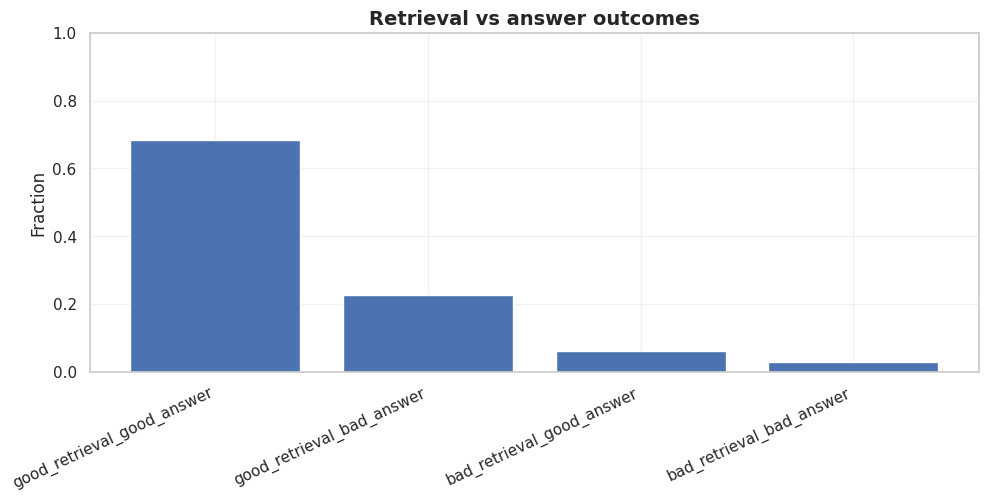

In [14]:
section("Retrieval vs generation", "Separate failure modes using recall_at_10 (labeled subset).")

src = eval_runs.copy()
if {"is_correct", "recall_at_10"}.issubset(src.columns):
    src["is_correct"] = to_num(src["is_correct"])
    src["recall_at_10"] = to_num(src["recall_at_10"])
    src = src.dropna(subset=["is_correct", "recall_at_10"]).copy()

    # Offline split for failure attribution: recall_at_10 >= 0.80 means most expected evidence
    # was recovered in the top 10. Tune this threshold for stricter/looser analysis policies.
    src["retrieval_ok"] = src["recall_at_10"] >= RETRIEVAL_OK_THRESHOLD
    src["gen_ok"] = src["is_correct"] == 1

    src["bucket"] = np.select(
        [
            src["retrieval_ok"] & src["gen_ok"],
            src["retrieval_ok"] & (~src["gen_ok"]),
            (~src["retrieval_ok"]) & src["gen_ok"],
            (~src["retrieval_ok"]) & (~src["gen_ok"]),
        ],
        [
            "good_retrieval_good_answer",
            "good_retrieval_bad_answer",
            "bad_retrieval_good_answer",
            "bad_retrieval_bad_answer",
        ],
        default="other",
    ).astype(str)

    retrieval_outcome_table = (
        src["bucket"]
        .value_counts(normalize=True)
        .rename("fraction")
        .reset_index()
        .sort_values("fraction", ascending=False)
        .reset_index(drop=True)
    )
    display(style_table(retrieval_outcome_table, max_rows=10, center_cols=["fraction"]))

    plt.figure(figsize=(10.2, 5.2))
    plt.bar(retrieval_outcome_table["bucket"].astype(str), retrieval_outcome_table["fraction"].astype(float))
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0, 1)
    plt.title("Retrieval vs answer outcomes")
    plt.ylabel("Fraction")
    plt.tight_layout()
    plt.show()
else:
    callout("warn", "Skipped", "Need is_correct + recall_at_10.")


feature,feature_type,note
n_retrieved_chunks,numeric,Retrieval-stage signal; observable after retrieval and before answer display.
top1_score,numeric,Retrieval-stage signal; observable after retrieval and before answer display.
mean_retrieved_score,numeric,Retrieval-stage signal; observable after retrieval and before answer display.
used_long_context_window,numeric,Runtime behavior flag; observable from system metadata.
answered_without_retrieval,numeric,Runtime behavior flag; observable from system metadata.
latency_ms_retrieval,numeric,Post-run operational signal; useful for diagnostics and SLA analysis.
latency_ms_generation,numeric,Post-run operational signal; useful for diagnostics and SLA analysis.
total_latency_ms,numeric,Post-run operational signal; useful for diagnostics and SLA analysis.
context_window_tokens,numeric,Token/size signal; useful for cost and context-pressure diagnostics.
answer_tokens,numeric,Token/size signal; useful for cost and context-pressure diagnostics.


model,roc_auc,avg_precision
LogisticRegression diagnostic baseline,0.697836,0.868374
Random baseline,0.500000,0.743985


              precision    recall  f1-score   support

           0      0.582     0.131     0.213       245
           1      0.764     0.968     0.854       711

    accuracy                          0.753       956
   macro avg      0.673     0.549     0.533       956
weighted avg      0.717     0.753     0.690       956



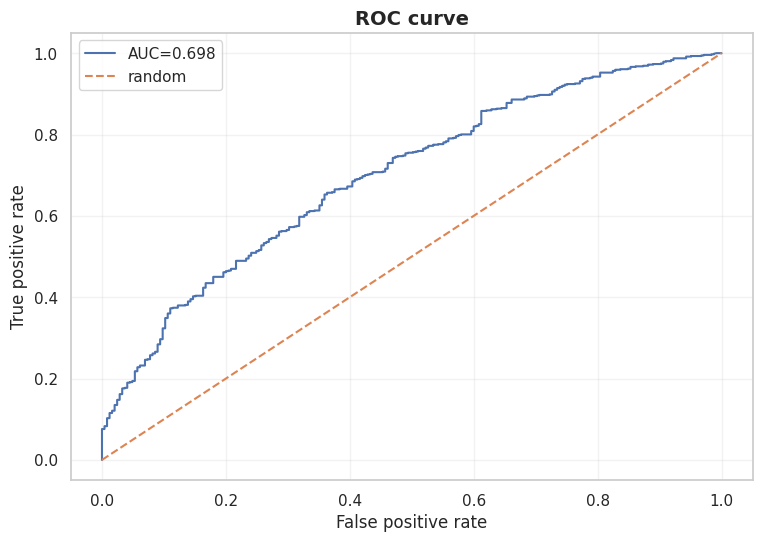

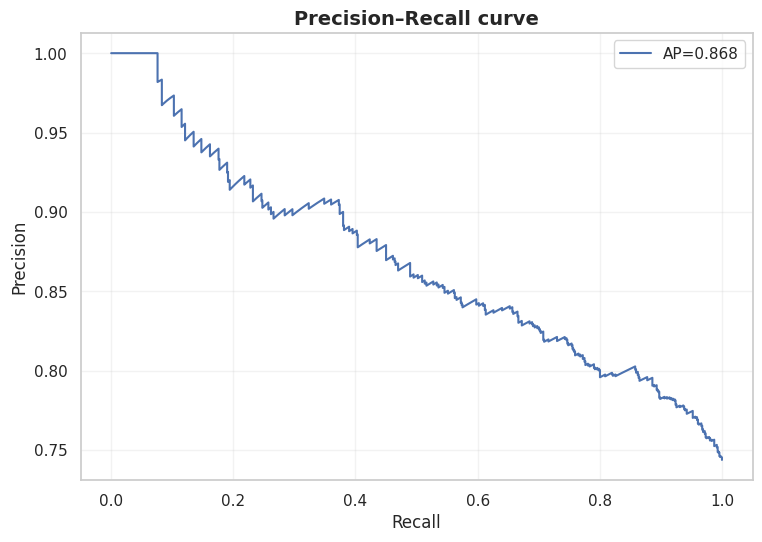

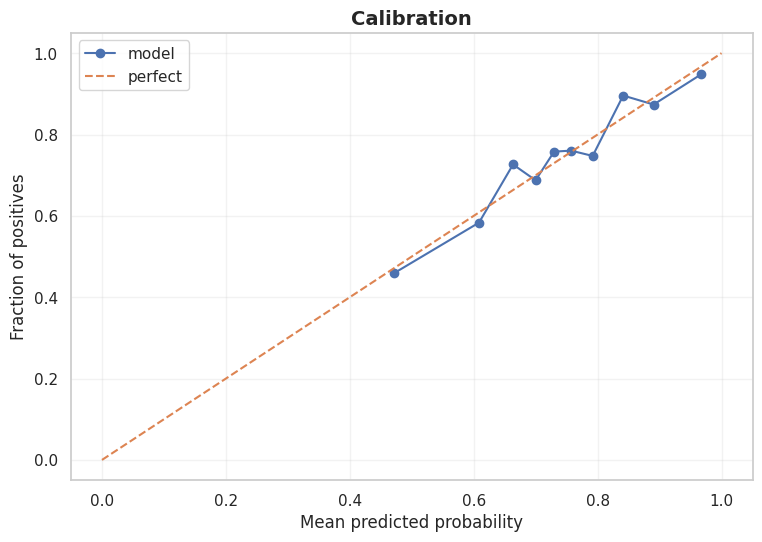

threshold,coverage,error_rate_on_shown
0.100000,1.000000,0.256276
0.200000,0.997908,0.254717
0.300000,0.997908,0.254717
0.400000,0.985356,0.250531
0.500000,0.942469,0.236404
0.600000,0.862971,0.216970
0.700000,0.653766,0.180800
0.800000,0.328452,0.111465
0.900000,0.123431,0.059322


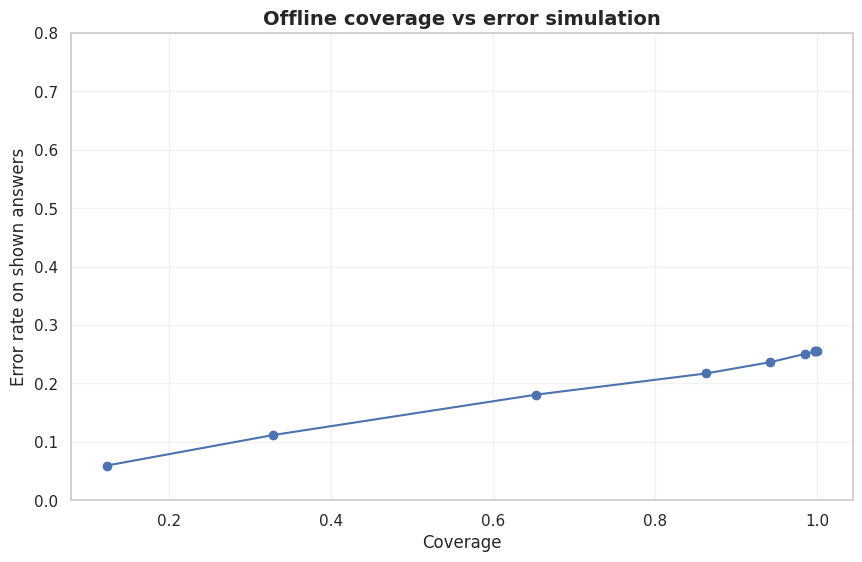

In [15]:
section(
    "Diagnostic baseline model",
    "LogisticRegression baseline using observable/post-run metadata only; excludes recall/MRR and other gold-label-derived features.",
)

callout(
    "warn",
    "Interpretation guardrail",
    "This baseline is an offline diagnostic for already-labeled evaluation logs. It should not be presented as a live gating rule without separate validation and a policy design using only features available before answer display.",
)

target = "is_correct"
src = eval_runs.copy()
if target in src.columns:
    src[target] = to_num(src[target])
    src = src.dropna(subset=[target]).copy()
else:
    src = pd.DataFrame()

# Keep the baseline honest: exclude offline/gold-derived retrieval labels such as recall_at_5, recall_at_10, mrr_at_10,
# has_relevant_in_top5, has_relevant_in_top10, correctness/faithfulness labels, and hallucination labels.
numeric_features = [c for c in [
    "n_retrieved_chunks", "top1_score", "mean_retrieved_score",
    "used_long_context_window", "answered_without_retrieval",
    "latency_ms_retrieval", "latency_ms_generation", "total_latency_ms",
    "context_window_tokens", "answer_tokens", "prompt_tokens", "total_cost_usd",
] if c in src.columns]

categorical_features = [c for c in [
    "domain", "task_type", "difficulty", "retrieval_strategy", "chunking_strategy",
    "embedding_model", "reranker_model", "generator_model", "eval_mode", "stop_reason",
] if c in src.columns]

feature_cols = numeric_features + categorical_features

def feature_note(feature: str) -> str:
    if feature in {"top1_score", "mean_retrieved_score", "n_retrieved_chunks"}:
        return "Retrieval-stage signal; observable after retrieval and before answer display."
    if "latency" in feature:
        return "Post-run operational signal; useful for diagnostics and SLA analysis."
    if feature in {"prompt_tokens", "answer_tokens", "context_window_tokens"}:
        return "Token/size signal; useful for cost and context-pressure diagnostics."
    if feature == "total_cost_usd":
        return "Post-run cost signal; useful for budget trade-off analysis."
    if feature in {"used_long_context_window", "answered_without_retrieval"}:
        return "Runtime behavior flag; observable from system metadata."
    if feature in {"stop_reason"}:
        return "Generation metadata; post-answer diagnostic signal."
    return "Categorical metadata; no gold relevance or correctness label used."

feature_audit = pd.DataFrame({
    "feature": feature_cols,
    "feature_type": ["numeric" if c in numeric_features else "categorical" for c in feature_cols],
    "note": [feature_note(c) for c in feature_cols],
})
display(style_table(feature_audit, max_rows=40, wrap_cols=["note"], center_cols=["feature_type"]))

if len(src) and len(feature_cols) and src[target].nunique() >= 2:
    X = src[feature_cols].copy()
    for c in numeric_features:
        X[c] = to_num(X[c]).replace([np.inf, -np.inf], np.nan)

    y = src[target].astype(int)
    base_rate = float(y.mean())

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y if y.nunique() > 1 else None,
    )

    # Compatible with both newer and older scikit-learn versions.
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

    transformers = []
    if numeric_features:
        transformers.append((
            "num",
            Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
            numeric_features,
        ))
    if categorical_features:
        transformers.append((
            "cat",
            Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", ohe)]),
            categorical_features,
        ))

    pre = ColumnTransformer(transformers=transformers)
    model = Pipeline([
        ("prep", pre),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])

    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    roc_auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)

    res = pd.DataFrame([
        {"model": "LogisticRegression diagnostic baseline", "roc_auc": roc_auc, "avg_precision": ap},
        {"model": "Random baseline", "roc_auc": 0.5, "avg_precision": base_rate},
    ])
    display(style_table(res, max_rows=10, center_cols=["roc_auc", "avg_precision"]))

    report_text = classification_report(y_test, pred, digits=3)
    report_dict = classification_report(y_test, pred, digits=3, output_dict=True)
    macro_f1 = float(report_dict.get("macro avg", {}).get("f1-score", np.nan))
    print(report_text)

    callout(
        "warn",
        "Class balance note",
        f"The positive class rate is {base_rate:.1%}. Accuracy can look acceptable when the model defaults toward the majority class; macro-average F1 = {macro_f1:.3f} and PR metrics are more informative for this diagnostic baseline.",
    )

    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.figure(figsize=(7.8, 5.6))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "--", label="random")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("ROC curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.figure(figsize=(7.8, 5.6))
    plt.plot(rec, prec, label=f"AP={ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    plt.figure(figsize=(7.8, 5.6))
    plt.plot(mean_pred, frac_pos, marker="o", label="model")
    plt.plot([0, 1], [0, 1], "--", label="perfect")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title("Calibration")
    plt.legend()
    plt.tight_layout()
    plt.show()

    calibration_gap = float(np.mean(np.abs(frac_pos - mean_pred))) if len(frac_pos) else np.nan
    brier = float(np.mean((proba - y_test.to_numpy()) ** 2))
    if np.isfinite(calibration_gap) and calibration_gap <= 0.05:
        calibration_label = "reasonably well calibrated for an exploratory baseline"
        calibration_caution = "the threshold simulation is interpretable as an offline diagnostic."
    elif np.isfinite(calibration_gap) and calibration_gap <= 0.10:
        calibration_label = "moderately calibrated"
        calibration_caution = "the threshold simulation is useful, but should be interpreted with caution."
    else:
        calibration_label = "not tightly calibrated"
        calibration_caution = "treat threshold values as ranking diagnostics rather than calibrated probabilities."

    callout(
        "warn",
        "Calibration readout",
        f"Mean absolute calibration gap = {calibration_gap:.3f}; Brier score = {brier:.3f}. "
        f"The model appears {calibration_label}; {calibration_caution}",
    )

    rows = []
    for thr in THRESHOLDS:
        mask = proba >= thr
        coverage = float(mask.mean())
        error_rate = float(1.0 - y_test[mask].mean()) if mask.sum() else np.nan
        rows.append({
            "threshold": float(thr),
            "coverage": coverage,
            "error_rate_on_shown": error_rate,
        })
    threshold_simulation_table = pd.DataFrame(rows)
    display(style_table(threshold_simulation_table, max_rows=25, center_cols=["threshold", "coverage", "error_rate_on_shown"]))

    plt.figure(figsize=(8.8, 5.8))
    plt.plot(threshold_simulation_table["coverage"], threshold_simulation_table["error_rate_on_shown"], marker="o")
    plt.xlabel("Coverage")
    plt.ylabel("Error rate on shown answers")
    plt.title("Offline coverage vs error simulation")
    plt.ylim(0, 0.8)
    plt.tight_layout()
    plt.show()
else:
    callout("warn", "Skipped", "Need labeled is_correct + usable features + both classes present.")


In [16]:
section("Key takeaways", "Data-backed summary from the notebook outputs.")

summary_rows = []

if "domain" in eval_runs.columns and "is_correct" in eval_runs.columns:
    domain_perf = (
        eval_runs.assign(is_correct=to_num(eval_runs["is_correct"]))
        .groupby("domain", dropna=False)
        .agg(n_rows=("run_id", "size"), correct_rate=("is_correct", "mean"))
        .query("n_rows >= @MIN_SLICE_N")
        .sort_values(["correct_rate", "n_rows"], ascending=[True, False])
        .reset_index()
    )
    if len(domain_perf):
        r = domain_perf.iloc[0]
        summary_rows.append({
            "takeaway": "Highest-priority quality slice",
            "evidence": f"domain={r['domain']} has correct_rate={r['correct_rate']:.3f} across n={int(r['n_rows'])} runs.",
            "action": "Start review here before optimizing smaller slices.",
        })

if isinstance(retrieval_outcome_table, pd.DataFrame) and len(retrieval_outcome_table):
    qrow = retrieval_outcome_table.sort_values("fraction", ascending=False).iloc[0]
    summary_rows.append({
        "takeaway": "Dominant retrieval/generation outcome",
        "evidence": f"{qrow['bucket']} accounts for {qrow['fraction']:.1%} of evaluated runs.",
        "action": "Use this attribution to decide whether retrieval coverage or answer grounding needs the first fix.",
    })

if isinstance(config_score_table, pd.DataFrame) and len(config_score_table):
    best = config_score_table.iloc[0]
    label_cols = [c for c in ["retrieval_strategy", "generator_model", "difficulty"] if c in config_score_table.columns]
    label = ", ".join(f"{c}={best[c]}" for c in label_cols)
    summary_rows.append({
        "takeaway": "Best heuristic config row",
        "evidence": f"{label}; score={best['score']:.3f}, correct_rate={best['correct_rate']:.3f}, hallucination_rate={best['hallucination_rate']:.3f}.",
        "action": "Treat as a shortlist candidate, then validate against explicit quality, latency, and cost requirements.",
    })

if isinstance(threshold_simulation_table, pd.DataFrame) and len(threshold_simulation_table):
    usable = threshold_simulation_table.dropna(subset=["error_rate_on_shown"]).copy()
    if len(usable):
        candidate = usable.sort_values(["error_rate_on_shown", "coverage"], ascending=[True, False]).iloc[0]
        summary_rows.append({
            "takeaway": "Offline threshold simulation",
            "evidence": f"threshold={candidate['threshold']:.2f} gives coverage={candidate['coverage']:.1%} and error_rate_on_shown={candidate['error_rate_on_shown']:.1%} on the held-out split.",
            "action": "Use only as an offline diagnostic; live gating would need separate validation and policy design.",
        })

if summary_rows:
    display(style_table(pd.DataFrame(summary_rows), max_rows=10, wrap_cols=["takeaway", "evidence", "action"]))
else:
    callout("warn", "No dynamic takeaways", "Required intermediate outputs were not available; review the tables above manually.")

takeaway,evidence,action
Highest-priority quality slice,domain=financial_reports has correct_rate=0.712 across n=771 runs.,Start review here before optimizing smaller slices.
Dominant retrieval/generation outcome,good_retrieval_good_answer accounts for 68.3% of evaluated runs.,Use this attribution to decide whether retrieval coverage or answer grounding needs the first fix.
Best heuristic config row,"retrieval_strategy=bm25_then_rerank, generator_model=gpt-4o-mini, difficulty=easy; score=0.880, correct_rate=0.962, hallucination_rate=0.000.","Treat as a shortlist candidate, then validate against explicit quality, latency, and cost requirements."
Offline threshold simulation,threshold=0.90 gives coverage=12.3% and error_rate_on_shown=5.9% on the held-out split.,Use only as an offline diagnostic; live gating would need separate validation and policy design.
